In [54]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,19-10-2018,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,21-05-2019,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,05-07-2019,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,19-11-2018,0.10,1,0


In [3]:
df.dropna(inplace = True)
df.drop_duplicates(inplace = True)

In [4]:
df["id"]=df["id"].astype(str)
df["host_id"]=df["host_id"].astype(str)
df["latitude"]=df["latitude"].astype(str)
df["longitude"]=df["longitude"].astype(str)

How does the data look mathematically ?

In [6]:
df.describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,38821.000000,38821.000000,38821.000000,38821.000000,38821.000000,38821.000000
mean,142.332526,5.869220,29.290255,1.373229,5.166611,114.886299
std,196.994756,17.389026,48.182900,1.680328,26.302954,129.529950
min,0.000000,1.000000,1.000000,0.010000,1.000000,0.000000
25%,69.000000,1.000000,3.000000,0.190000,1.000000,0.000000
50%,101.000000,2.000000,9.000000,0.720000,1.000000,55.000000
75%,170.000000,4.000000,33.000000,2.020000,2.000000,229.000000
max,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


range of minimum nights for listings in 1 and 1250

# Categorical Data

In [9]:
df.nunique()

id                                38821
name                              38244
host_id                           30232
host_name                          9885
neighbourhood_group                   5
neighbourhood                       218
latitude                          17436
longitude                         13639
room_type                             3
price                               581
minimum_nights                       89
number_of_reviews                   393
last_review                        1764
reviews_per_month                   937
calculated_host_listings_count       47
availability_365                    366
dtype: int64

In [10]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [11]:
df["room_type"].value_counts()

room_type
Entire home/apt    20321
Private room       17654
Shared room          846
Name: count, dtype: int64

In [12]:
df["room_type"].value_counts(normalize = True)

room_type
Entire home/apt    0.523454
Private room       0.454754
Shared room        0.021792
Name: proportion, dtype: float64

In [13]:
df["neighbourhood_group"].value_counts()

neighbourhood_group
Manhattan        16621
Brooklyn         16439
Queens            4572
Bronx              875
Staten Island      314
Name: count, dtype: int64

In [14]:
df_n = df["neighbourhood"].value_counts().reset_index().rename(columns = {"index" : "neighbourhood" , "neighbourhood": "number_of_hotels"})

In [15]:
df_n

,number_of_hotels,count
0,Williamsburg,3163
1,Bedford-Stuyvesant,3141
2,Harlem,2204
3,Bushwick,1942
4,Hell's Kitchen,1528
...,...,...
213,Holliswood,2
214,New Dorp Beach,2
215,Richmondtown,1
216,Rossville,1


# Numerical Data

In [17]:
df["price"].value_counts(bins = 5)

(-10.001, 2000.0]    38786
(2000.0, 4000.0]        20
(4000.0, 6000.0]         8
(8000.0, 10000.0]        5
(6000.0, 8000.0]         2
Name: count, dtype: int64

In [18]:
bins = [-10,0, 50,100, 200,500,800,2000,4000,10000]
df["price"].value_counts(bins = bins)


(50.0, 100.0]        14212
(100.0, 200.0]       13544
(200.0, 500.0]        5267
(0.0, 50.0]           5166
(500.0, 800.0]         404
(800.0, 2000.0]        183
(2000.0, 4000.0]        20
(4000.0, 10000.0]       15
(-10.001, 0.0]          10
Name: count, dtype: int64

It is mainly helpful in small datasets.

## Measures of central tendency

In [21]:
df["price"].mean()

142.33252621004095

In [22]:
df["price"].median()

101.0

In [23]:
df["price"].std()

196.99475591833985

In [24]:
df["price"].kurt()

953.4807356344944

## Categorical 
### Bar Graph

In [26]:
df = pd.read_csv("AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,19-10-2018,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,21-05-2019,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,05-07-2019,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,19-11-2018,0.10,1,0


In [56]:
sns.set_palette("deep")

In [106]:
colors_1 = sns.color_palette("dark",5) ## we use 5 because we need 5 parameter

In [108]:
colors_2 = sns.color_palette("dark",3)

<Axes: xlabel='room_type', ylabel='count'>

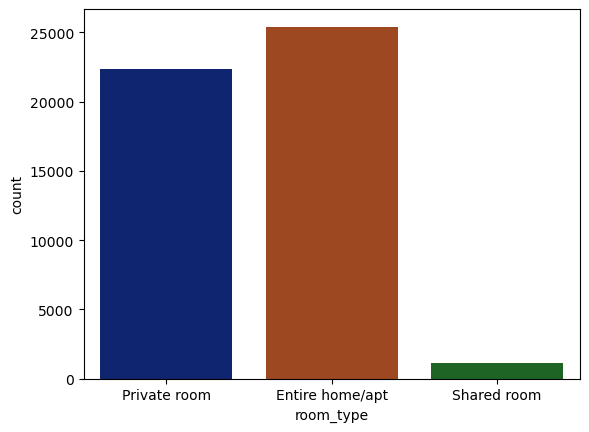

In [112]:
sns.countplot(data = df , x="room_type",hue = "room_type",palette = colors_2)

<Axes: xlabel='neighbourhood_group', ylabel='count'>

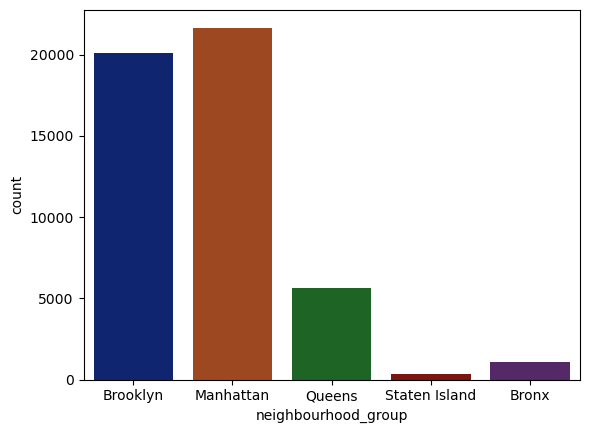

In [110]:
sns.countplot(data =df, x="neighbourhood_group",hue = "neighbourhood_group",palette = colors_1)

<Axes: xlabel='neighbourhood_group', ylabel='count'>

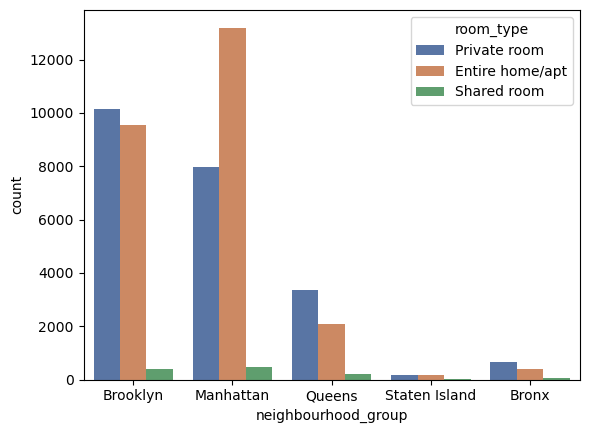

In [114]:
sns.countplot(data = df, x="neighbourhood_group" , hue = "room_type")

## Pie Chart

<Axes: ylabel='count'>

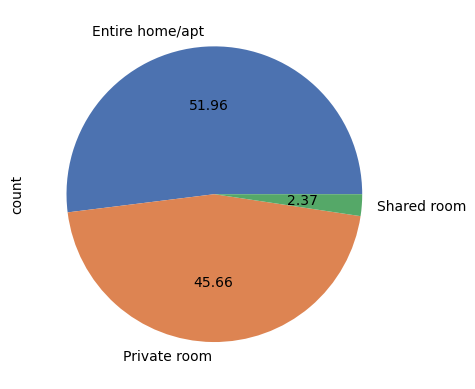

In [117]:
df["room_type"].value_counts().plot(kind = "pie", autopct = "%.2f")

<Axes: xlabel='availability_365'>

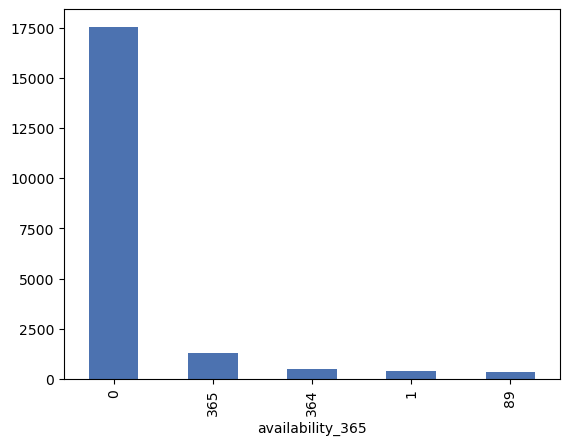

In [125]:
df["availability_365"].value_counts().head().plot(kind = "bar")

In [127]:
df2 = sns.load_dataset("titanic")
df2.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='survived', ylabel='count'>

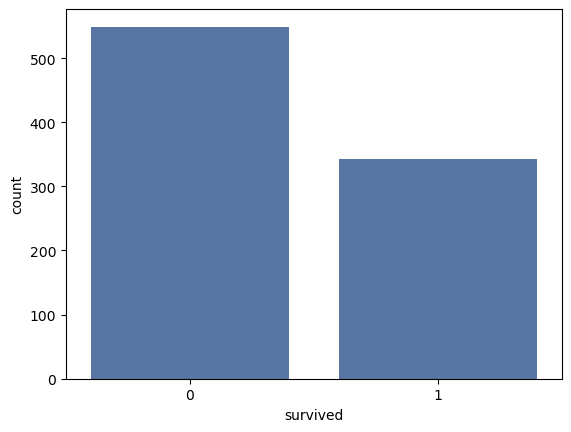

In [129]:
sns.countplot(x= df2["survived"])

<Axes: xlabel='embark_town', ylabel='count'>

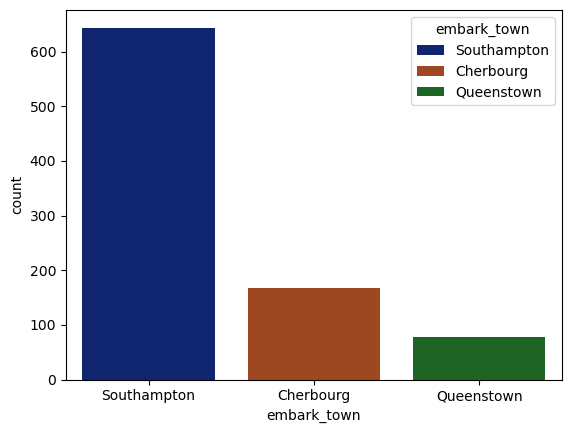

In [139]:
sns.countplot(data = df2,x="embark_town",hue = "embark_town",palette = colors_2)

<Axes: ylabel='count'>

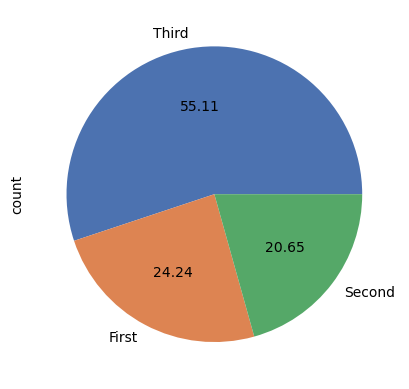

In [147]:
df2["class"].value_counts().plot(kind = "pie", autopct = "%.2f")

In [157]:
colors_3 = sns.color_palette("bright",2)

<Axes: xlabel='alone', ylabel='count'>

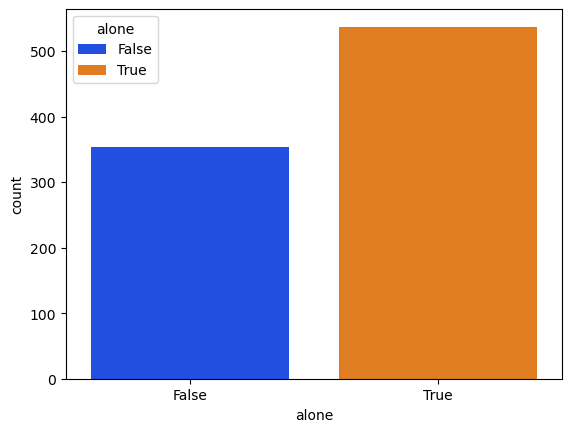

In [159]:
sns.countplot(data = df2,x = "alone",hue = "alone",palette = colors_3)

# Univariate Visualizations(Numerical)

In [163]:
df = pd.read_csv("AB_NYC_2019.csv")
df.head(2)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,19-10-2018,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,21-05-2019,0.38,2,355


## Histogram

<Axes: xlabel='price', ylabel='Count'>

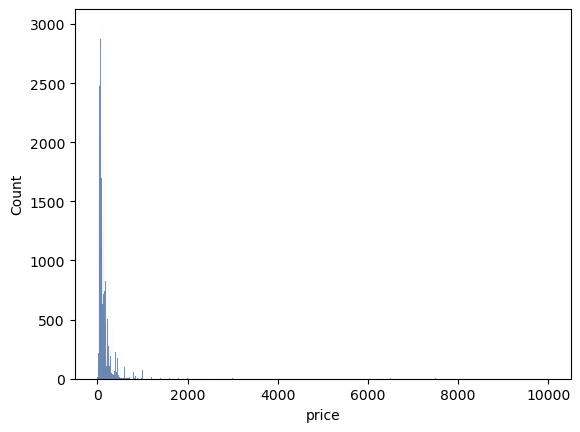

In [166]:
sns.histplot(data = df, x = "price")

<Axes: xlabel='price', ylabel='Count'>

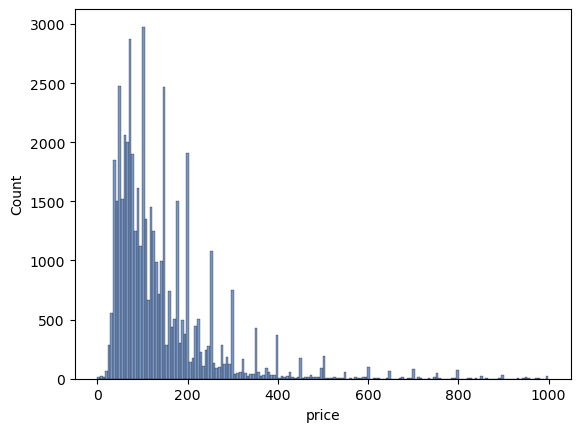

In [172]:
sns.histplot(data = df[df["price"]<1000], x = "price" )

<Axes: xlabel='price', ylabel='Count'>

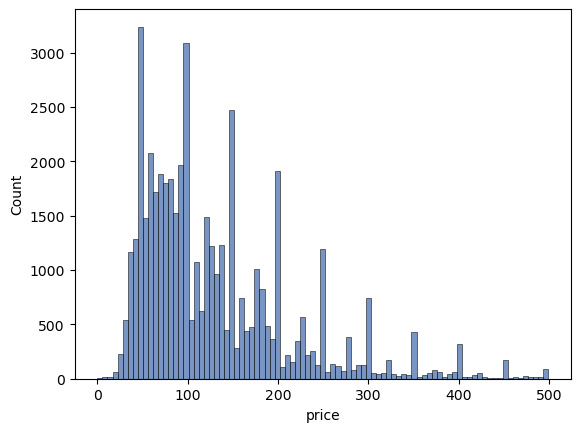

In [174]:
sns.histplot(data = df[df["price"]<500], x = "price" )

<Axes: xlabel='availability_365', ylabel='Count'>

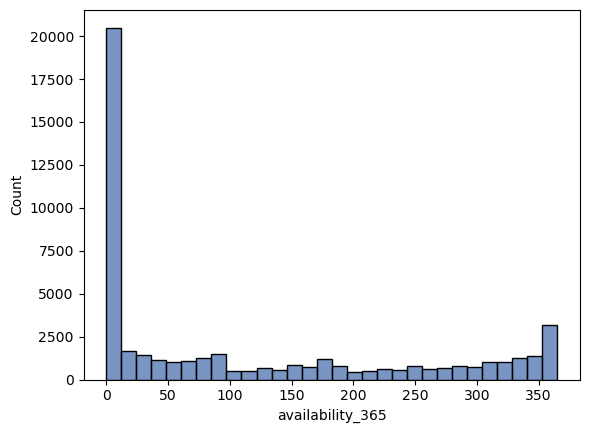

In [178]:
sns.histplot(data = df, x = "availability_365" )

<Axes: xlabel='number_of_reviews', ylabel='Count'>

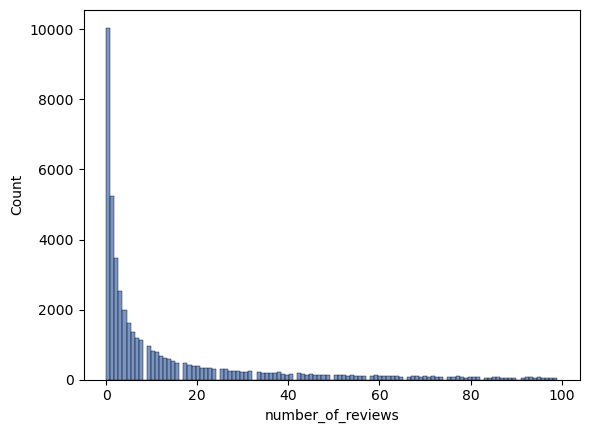

In [180]:
sns.histplot(df[df["number_of_reviews"]<100]["number_of_reviews"])


## Distribution

C:\Users\Satyam Jha\AppData\Local\Temp\ipykernel_5084\50337492.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["price"])


<Axes: xlabel='price', ylabel='Density'>

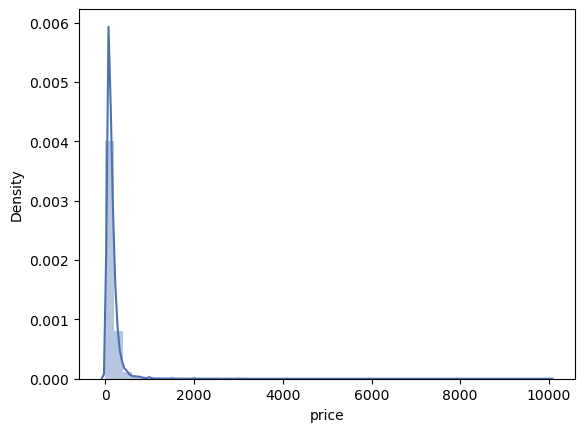

In [187]:
sns.distplot(df["price"])

C:\Users\Satyam Jha\AppData\Local\Temp\ipykernel_5084\2533210752.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["reviews_per_month"])


<Axes: xlabel='reviews_per_month', ylabel='Density'>

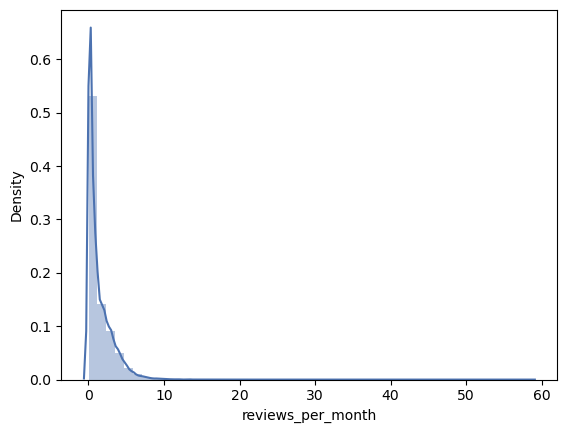

In [189]:
sns.distplot(df["reviews_per_month"])

## Boxplot

<Axes: ylabel='price'>

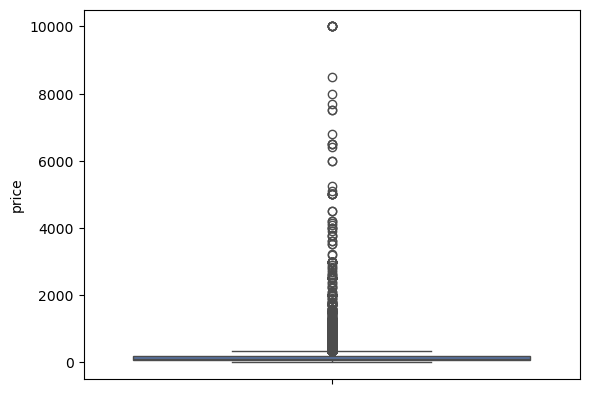

In [192]:
sns.boxplot(df["price"])

<Axes: ylabel='availability_365'>

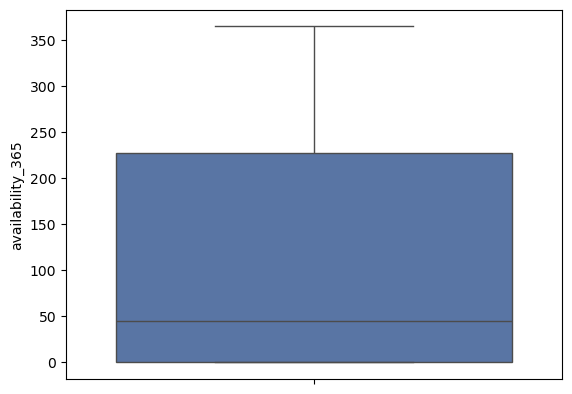

In [196]:
sns.boxplot(df["availability_365"])

<Axes: ylabel='availability_365'>

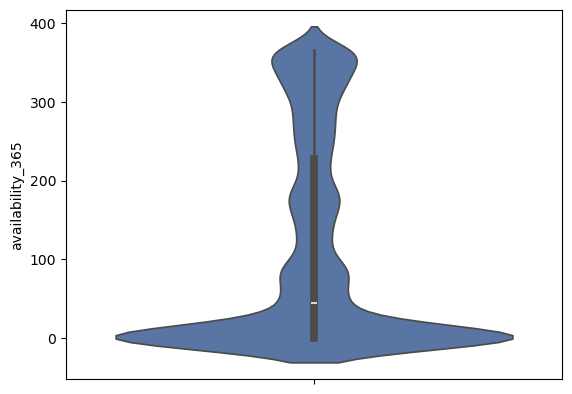

In [216]:
sns.violinplot(df["availability_365"])

In [198]:
df2 = sns.load_dataset("titanic")

In [200]:
df2.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='fare', ylabel='Count'>

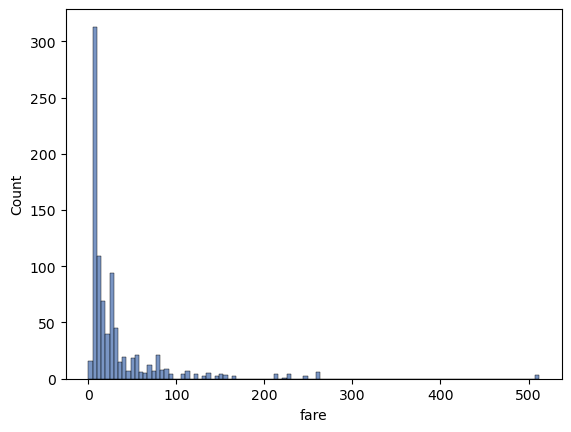

In [202]:
sns.histplot(data=df2 , x = "fare")

C:\Users\Satyam Jha\AppData\Local\Temp\ipykernel_5084\3524834500.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df2["fare"])


<Axes: xlabel='fare', ylabel='Density'>

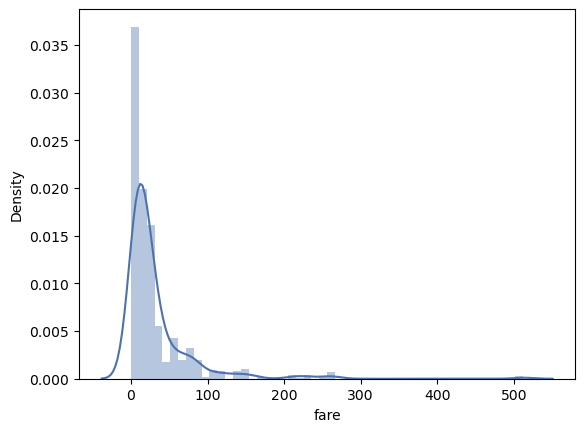

In [204]:
sns.distplot(df2["fare"])

<Axes: ylabel='fare'>

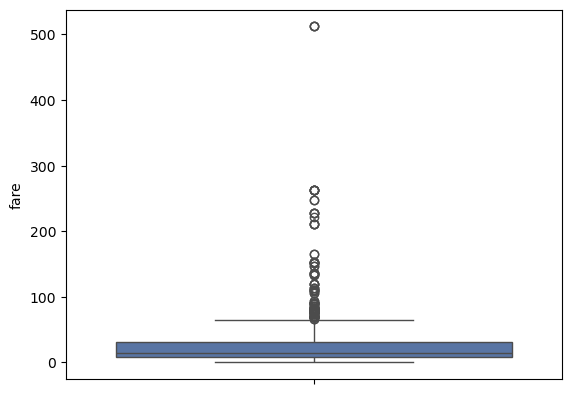

In [206]:
sns.boxplot(df2["fare"])

<Axes: ylabel='age'>

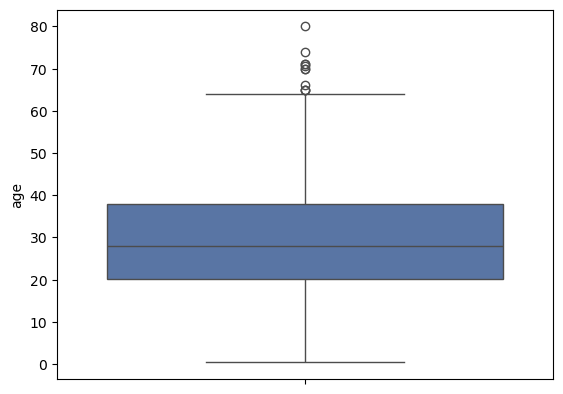

In [208]:
sns.boxplot(df2["age"])

<Axes: ylabel='age'>

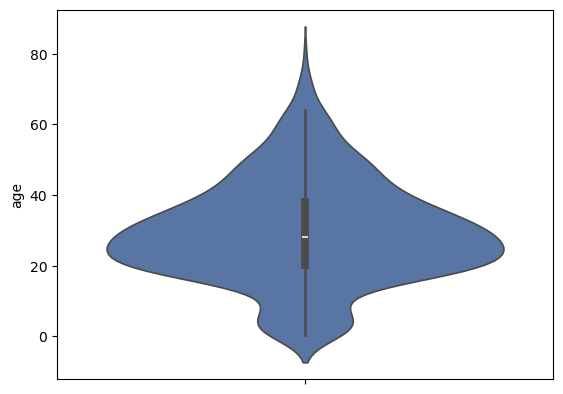

In [210]:
sns.violinplot(df2["age"])

# *Bivariate Analysis - Numerical-Categorical

In [219]:
df= sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='class', ylabel='age'>

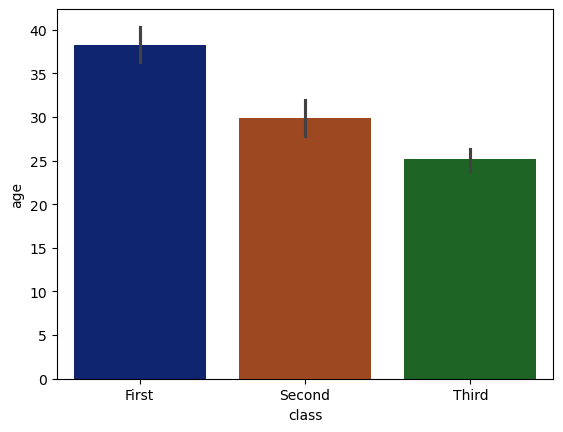

In [223]:
sns.barplot(x="class", y="age", data=df, hue="class", palette=colors, legend=False)

<Axes: xlabel='class', ylabel='age'>

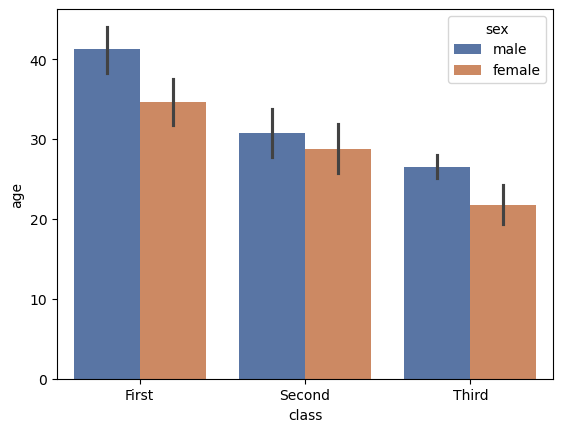

In [225]:
sns.barplot(x ="class", y= "age",hue = "sex", data = df)


<Axes: xlabel='class', ylabel='age'>

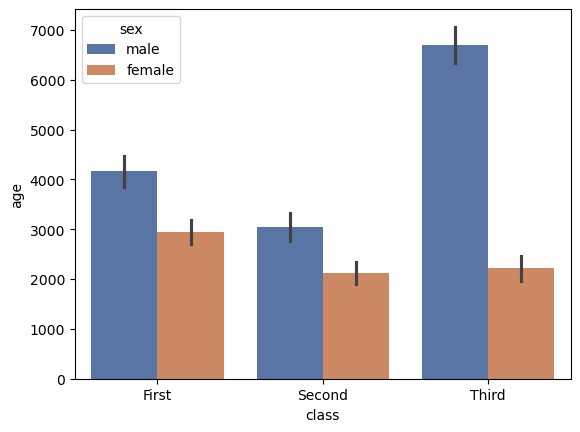

In [227]:
sns.barplot(x ="class", y= "age",hue = "sex",estimator="sum", data = df)

<Axes: xlabel='sex', ylabel='age'>

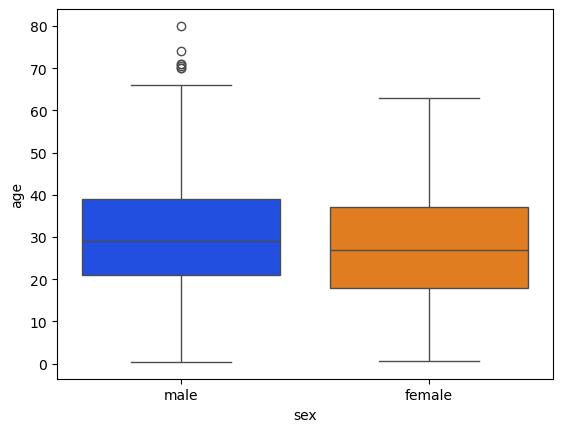

In [239]:
sns.boxplot(x="sex", y="age", data=df, hue="sex", palette=colors_3, legend=False)

<Axes: xlabel='sex', ylabel='age'>

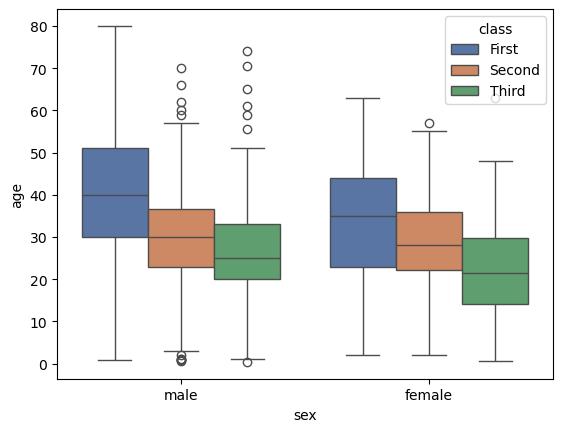

In [241]:
sns.boxplot(x = "sex", y= "age", hue = "class", data = df)

C:\Users\Satyam Jha\AppData\Local\Temp\ipykernel_5084\35758194.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df["survived"]==0]["age"], hist = False)
C:\Users\Satyam Jha\AppData\Local\Temp\ipykernel_5084\35758194.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[d

<Axes: xlabel='age', ylabel='Density'>

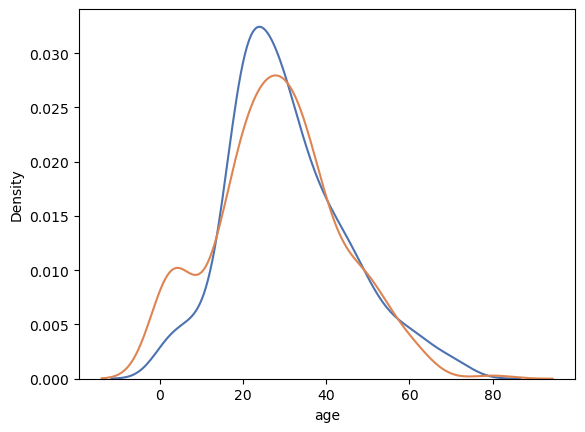

In [243]:
sns.distplot(df[df["survived"]==0]["age"], hist = False)
sns.distplot(df[df["survived"]==1]["age"], hist = False)

<Axes: xlabel='sex', ylabel='fare'>

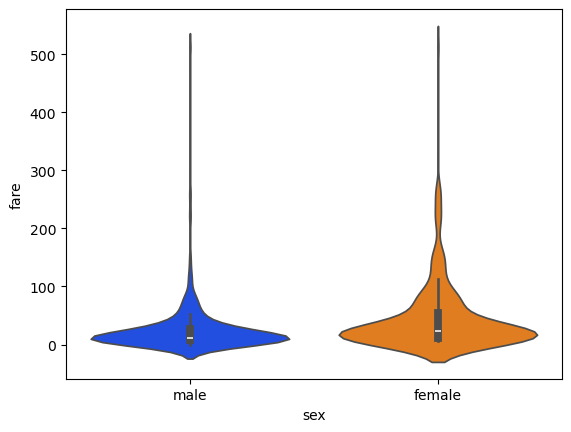

In [249]:
sns.violinplot(x = "sex", y = "fare", data = df,hue="sex",palette = colors_3,legend = False)

<Axes: xlabel='sex', ylabel='age'>

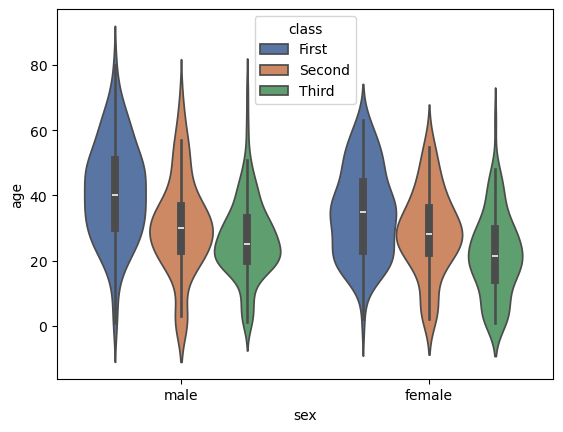

In [251]:
sns.violinplot(x = "sex", y= "age", hue = "class", data = df)

<Axes: xlabel='class', ylabel='age'>

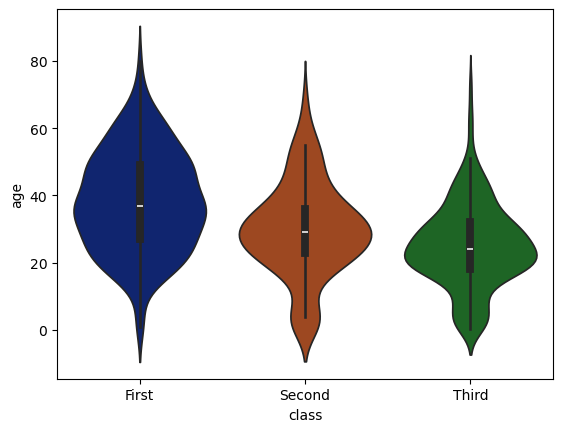

In [255]:
sns.violinplot(x = "class" , y = "age" , data = df , hue = "class" , palette = colors,legend = False)

# Bivariate Visualization(Categorical)

In [283]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='sex', ylabel='age'>

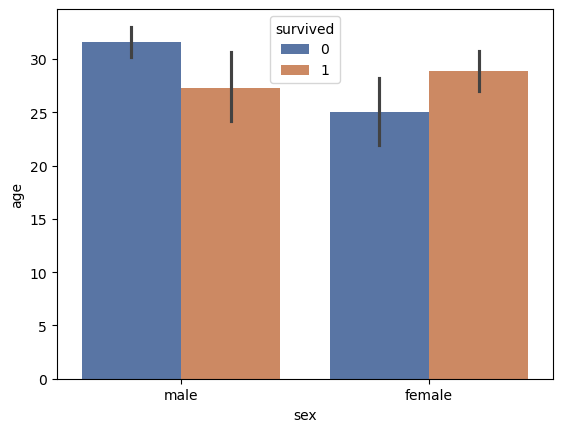

In [261]:
sns.barplot(x = "sex", y= "age",hue = "survived" ,data = df)

<Axes: xlabel='sex', ylabel='age'>

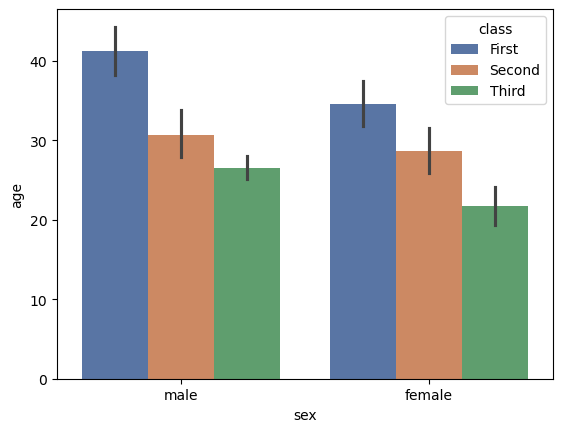

In [265]:
sns.barplot(x = "sex", y= "age",hue = "class" ,data = df)

In [267]:
x = pd.crosstab(df["survived"],df["class"])

In [269]:
x

class,First,Second,Third
survived,,,
0,80,97,372
1,136,87,119


<Axes: xlabel='class', ylabel='survived'>

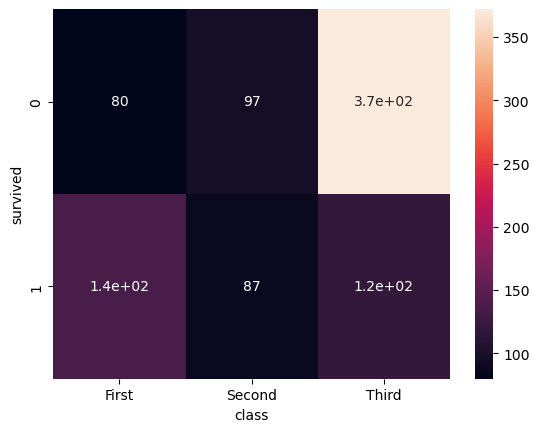

In [273]:
sns.heatmap(x,annot = True)

<Axes: xlabel='class', ylabel='age'>

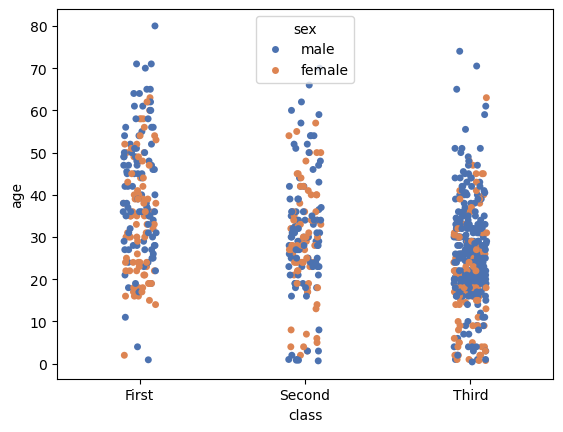

In [263]:
sns.stripplot(x="class", y= "age",hue = "sex", data = df)

<Axes: xlabel='class', ylabel='survived'>

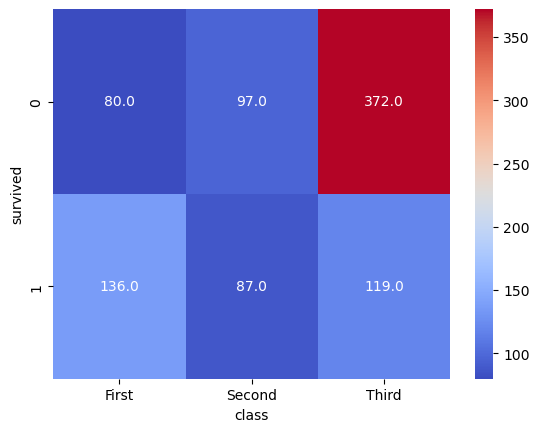

In [275]:
sns.heatmap(x,annot = True ,fmt = ".1f",cmap="coolwarm")

<Axes: xlabel='class', ylabel='age'>

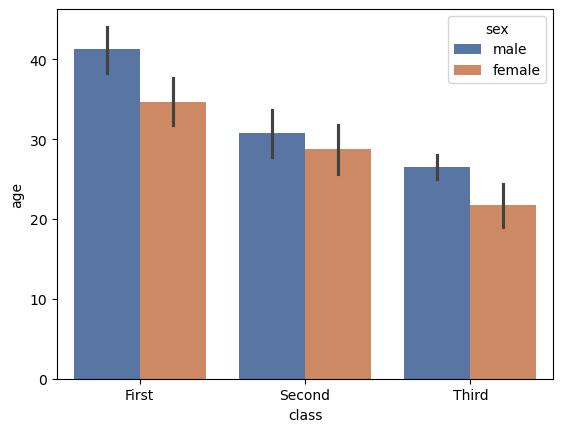

In [277]:
sns.barplot(x = "class", y = "age", hue ="sex" , data = df)

In [281]:
df2 = sns.load_dataset("iris")
df2.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: >

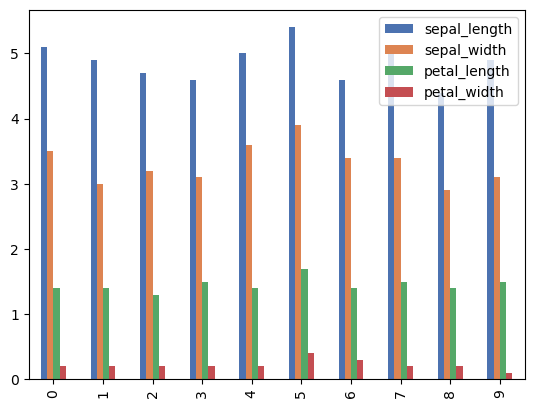

In [285]:
df2.head(10).plot(kind = "bar")

<Axes: >

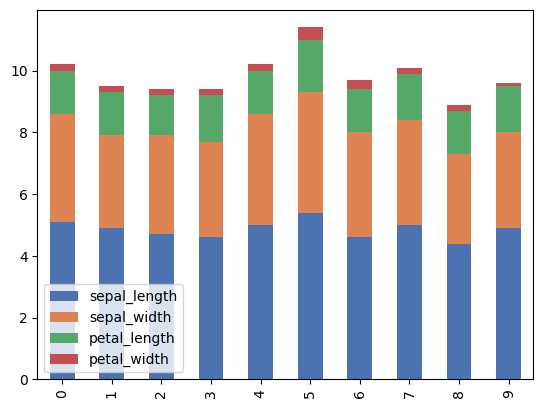

In [287]:
df2.head(10).plot(kind = "bar", stacked = True)

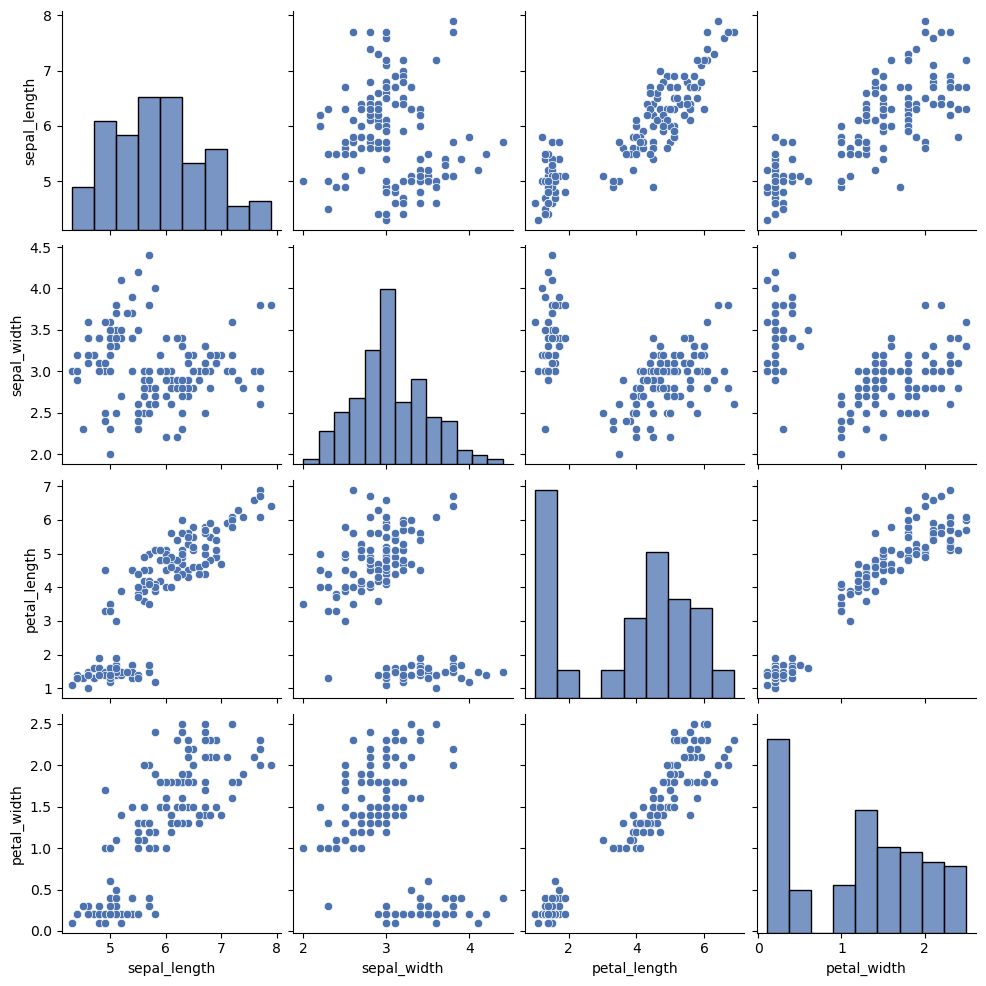

In [289]:
sns.pairplot(df2)